In [1]:
import numpy as np
from utils import *
from upload_utils import *
from model_utils import *
from datetime import datetime, timedelta
import pandas as pd
import time
import os, pickle, json
from datetime import datetime

In [2]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from datetime import datetime, timedelta
import geopandas as gpd


In [3]:
geo_data = gpd.read_file('./data_imdc_2026/shape_muni.gpkg')
geo_data.head()

,geocode,geocode_name,uf,uf_code,geometry
0,1100015,Alta Floresta D'oeste,RO,11,"MULTIPOLYGON (((-61.96836 -12.13407, -61.96827..."
1,1100023,Ariquemes,RO,11,"MULTIPOLYGON (((-63.18282 -10.13892, -63.18615..."
2,1100031,Cabixi,RO,11,"MULTIPOLYGON (((-60.70518 -13.32474, -60.70904..."
3,1100049,Cacoal,RO,11,"MULTIPOLYGON (((-61.3474 -11.50562, -61.34569 ..."
4,1100056,Cerejeiras,RO,11,"MULTIPOLYGON (((-60.82417 -13.11156, -60.82289..."


In [4]:
# State administrative mapping for competition submission
adm_1_map = {
    'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM', 'Bahia': 'BA', 'Ceará': 'CE',
    'Distrito Federal': 'DF', 'Goiás': 'GO', 'Maranhão': 'MA', 'Mato Grosso': 'MT',
    'Mato Grosso do Sul': 'MS', 'Minas Gerais': 'MG', 'Pará': 'PA', 'Paraíba': 'PB',
    'Paraná': 'PR', 'Pernambuco': 'PE', 'Piauí': 'PI', 'Rio de Janeiro': 'RJ', 'Rio Grande do Norte': 'RN',
    'Rio Grande do Sul': 'RS', 'Rondônia': 'RO', 'Roraima': 'RR', 'Santa Catarina': 'SC',
    'São Paulo': 'SP', 'Sergipe': 'SE', 'Tocantins': 'TO'
}

# Complete list of Brazilian states for analysis ()
brazilian_states = [
    'Acre', 'Alagoas', 'Amapá', 'Amazonas', 'Bahia', 'Ceará',
    'Distrito Federal', 'Goiás', 'Maranhão', 'Mato Grosso',
    'Mato Grosso do Sul', 'Minas Gerais', 'Pará', 'Paraíba',
    'Paraná', 'Pernambuco', 'Piauí', 'Rio de Janeiro', 'Rio Grande do Norte',
    'Rio Grande do Sul', 'Rondônia', 'Roraima', 'Santa Catarina',
    'São Paulo', 'Sergipe', 'Tocantins'
]

In [5]:
all_major = []
for state in brazilian_states:

    state = adm_1_map[state]
    print(state)
    major_cities_dir = f"./data_imdc_2026/major_cities/{state}"
    os.makedirs(major_cities_dir, exist_ok=True)
    major_cities_cache_file = os.path.join(major_cities_dir, "major.pickle")

    with open(major_cities_cache_file, 'rb') as f:
        major_cities = pickle.load(f)

    for city in major_cities:
        all_major.append(city)

all_major = set(all_major)

AC
AL
AP
AM
BA
CE
DF
GO
MA
MT
MS
MG
PA
PB
PR
PE
PI
RJ
RN
RS
RO
RR
SC
SP
SE
TO


In [14]:
missing_weeks = ['2026-03-15', '2026-03-22', '2026-03-29', '2026-04-05', '2026-04-12', '2026-04-19', '2026-04-26', '2026-05-03', 
                 '2026-05-10', '2026-05-17', '2026-05-24', '2026-05-31', '2026-06-07', '2026-06-14', '2026-06-21', '2026-06-28', 
                 '2026-07-05', '2026-07-12', '2026-07-19', '2026-07-26',  '2026-08-02', '2026-08-09', '2026-08-16', '2026-08-23', 
                 '2026-08-30', '2026-09-06', '2026-09-13', '2026-09-20', '2026-09-27', '2026-10-04']

len_mw = len(missing_weeks)
len_md = len_mw * 7
len_md

210

In [56]:
weather_data = pd.read_parquet('./data_imdc_2026/weather_data_daily.parquet')
weather_data = weather_data[weather_data.date >= '2025-01-01']

In [57]:
weather_data.head()

,geocode,date,epiweek,temp_med,precip_med,pressure_med,rel_humid_med
5477,1100031,2025-01-01,NaN,25.497492,2.591786,0.969527,83.539341
5478,1100031,2025-01-02,NaN,25.306222,2.884929,0.969559,84.391516
5479,1100031,2025-01-03,NaN,25.142262,3.145162,0.969579,85.160434
5480,1100031,2025-01-04,NaN,25.005612,3.372487,0.969586,85.846093
5481,1100031,2025-01-05,202502.0,24.896270,3.566903,0.969580,86.448495


In [106]:
print(weather_data['date'].dtype)

datetime64[ns]


In [107]:
weather_data.date.max()

Timestamp('2026-03-15 00:00:00')

In [88]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import pyarrow.parquet as pq

# Define your date range
start_date = '2026-03-15'
end_date = '2026-10-04'

# Convert to datetime
start_dt = pd.to_datetime(start_date)
end_dt = pd.to_datetime(end_date)

# Ensure the date column is datetime
# Assuming your date column is named 'date' - adjust accordingly
weather_data['date'] = pd.to_datetime(weather_data['date'])

# Get dates for the last 3 years (including 2026)
years = [2023, 2024, 2025]  # Last 3 years

# Filter data for each year
filtered_dfs = []
for year in years:
    # Create date range for this year's period
    year_start = pd.Timestamp(f'{year}-{start_dt.month:02d}-{start_dt.day:02d}')
    year_end = pd.Timestamp(f'{year}-{end_dt.month:02d}-{end_dt.day:02d}')
    
    # Filter data for this year's period
    mask = (weather_data['date'] >= year_start) & (weather_data['date'] <= year_end)
    filtered_dfs.append(weather_data.loc[mask])

# Combine all filtered data
filtered_df = pd.concat(filtered_dfs, ignore_index=True)

# Identify numeric columns (excluding date column)
numeric_cols = ['temp_med','precip_med','pressure_med','rel_humid_med']

# remove year, i want average of each day in the 3 years
filtered_df['date'] = filtered_df['date'].apply(lambda x: str(x)[5:])

# Group by date and calculate mean for all numeric columns
daily_averages = filtered_df.groupby(['geocode','date'])[numeric_cols].mean().reset_index()

# add back the year
daily_averages['date'] = daily_averages['date'].apply(lambda x: pd.to_datetime('2026-'+str(x)))

# Sort by date
daily_averages = daily_averages.sort_values('date')

# Display results
print(f"Data from {len(years)} years for period {start_date} to {end_date}")
print(f"Total days with data: {len(daily_averages)}")
print("\nDaily averages for numeric variables:")
print(daily_averages.head(10))  # Show first 10 days



Data from 3 years for period 2026-03-15 to 2026-10-04
Total days with data: 51000

Daily averages for numeric variables:
       geocode       date   temp_med  precip_med  pressure_med  rel_humid_med
0      1100031 2026-03-15  26.239532    1.454521      0.971623      85.418088
7344   1400456 2026-03-15  25.930526    1.654791      0.959864      73.089292
39372  4116000 2026-03-15  25.181113    1.175673      0.945715      67.779166
39576  4116505 2026-03-15  25.727426    1.363222      0.958056      66.740241
7140   1400407 2026-03-15  26.947028    0.947606      0.978265      70.397056
39780  4123600 2026-03-15  26.475232    0.985096      0.957745      63.928419
6936   1400308 2026-03-15  25.919263    2.449641      0.974438      80.270038
39984  4124301 2026-03-15  22.175441    1.124099      0.919805      75.859257
40188  4125555 2026-03-15  25.706816    1.344668      0.959806      66.660171
6732   1400282 2026-03-15  25.466208    2.579204      0.967011      81.645064


In [89]:
daily_averages.head()

,geocode,date,temp_med,precip_med,pressure_med,rel_humid_med
0,1100031,2026-03-15,26.239532,1.454521,0.971623,85.418088
7344,1400456,2026-03-15,25.930526,1.654791,0.959864,73.089292
39372,4116000,2026-03-15,25.181113,1.175673,0.945715,67.779166
39576,4116505,2026-03-15,25.727426,1.363222,0.958056,66.740241
7140,1400407,2026-03-15,26.947028,0.947606,0.978265,70.397056


<Axes: xlabel='date'>

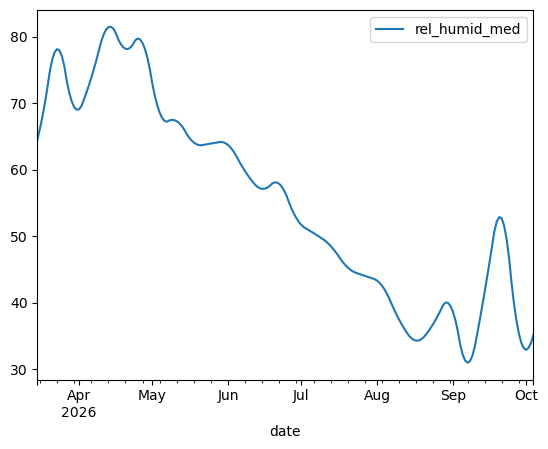

In [90]:
daily_averages[daily_averages.geocode == 5300108].plot(x='date',y='rel_humid_med')

In [100]:
forecasted_weather = pd.concat([daily_averages, weather_data]).sort_values('date')
forecasted_weather

,geocode,date,temp_med,precip_med,pressure_med,rel_humid_med,epiweek
526085,2210383,2025-01-01,30.187269,0.776788,0.975192,56.737876,NaN
1377989,5106315,2025-01-01,26.600182,5.363043,0.973527,82.187712,NaN
928373,2918704,2025-01-01,25.373161,1.405716,0.926149,67.974241,NaN
768641,2700805,2025-01-01,26.785280,0.480378,0.966422,68.872561,NaN
679901,2505303,2025-01-01,30.290651,0.052524,0.947688,44.358496,NaN
...,...,...,...,...,...,...,...
37331,3515806,2026-10-04,27.523821,0.391913,0.960101,50.616264,NaN
37127,3515657,2026-10-04,24.489946,0.906850,0.937745,55.582965,NaN
36923,3513850,2026-10-04,28.783658,0.795158,0.955516,44.711124,NaN
26723,2702702,2026-10-04,24.442497,1.004973,0.999235,78.712401,NaN


In [108]:
# Convert date column to strings
forecasted_weather['date'] = forecasted_weather['date'].astype(str)
# Conver back to datetime
forecasted_weather['date'] = pd.to_datetime(forecasted_weather['date'])

# Or if you want a specific string format
#forecasted_weather['date'] = forecasted_weather['date'].dt.strftime('%Y-%m-%d')

# Verify the change
print(forecasted_weather['date'].dtype)  # Should show 'object' (which means string)
print(forecasted_weather['date'].head())

datetime64[ns]
526085    2025-01-01
1377989   2025-01-01
928373    2025-01-01
768641    2025-01-01
679901    2025-01-01
Name: date, dtype: datetime64[ns]


In [109]:
forecasted_weather.to_parquet('./data_imdc_2026/forecasted_weather_daily.parquet', engine='fastparquet')

<Axes: xlabel='date'>

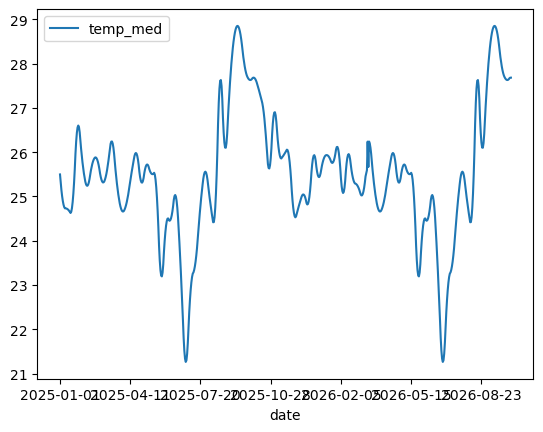

In [104]:
forecasted_weather[forecasted_weather.geocode==1100031].plot(x='date',y='temp_med')

<Axes: xlabel='date'>

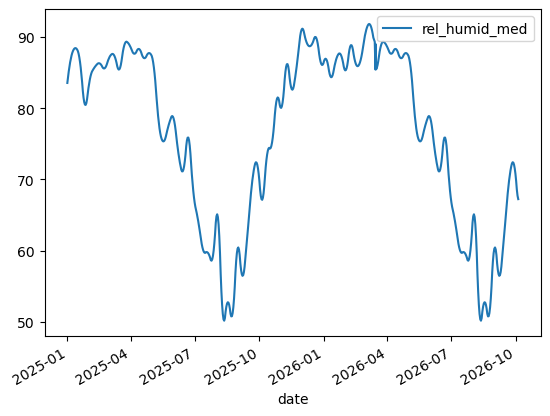

In [95]:
forecasted_weather[forecasted_weather.geocode==1100031].plot(x='date',y='rel_humid_med')